# Salary Analysis by Position Level

## Research Question

How do advertised monthly salaries differ by position level in Singapore IT job postings?

## Objective

This analysis compares the number of job postings, median salary and typical salary range across different IT position levels.

The analysis uses the team's cleaned dataset, which contains 140,506 unique IT job postings.

In [1]:
# ============================================================
# STEP 1: LOAD THE CLEANED TEAM DATASET
# ============================================================

# Import Pandas for data analysis.
import pandas as pd

# Load the final dataset created by the team cleaning process.
salary = pd.read_csv(
    "jobs_clean.csv",
    low_memory=False
)

# Display the number of rows and columns.
print("Dataset shape:", salary.shape)

# Display the first five rows.
display(salary.head())

Dataset shape: (140506, 36)


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,average_salary_raw,salary_ratio_before_correction,salary_maximum_corrected,posting_month,from_may_2023_flag,salary_midpoint,salary_band_width,category_count,experience_review_flag,position_level_missing_flag
0,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,4750.0,1.375,False,2023-04,False,4750.0,1500.0,1,False,False
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,7500.0,2.000,False,2023-04,False,7500.0,5000.0,1,False,False
2,"[{""id"":7,""category"":""Consulting""},{""id"":21,""ca...",Full Time,2023-04-22,False,MCF-2023-0273974,2023-04-08,2023-04-08,0,4,110,...,5000.0,1.500,False,2023-04,False,5000.0,2000.0,3,False,False
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273984,2023-04-08,2023-04-08,0,28,171,...,9000.0,1.250,False,2023-04,False,9000.0,2000.0,1,False,False
4,"[{""id"":11,""category"":""Engineering""},{""id"":21,""...",Permanent,2023-05-12,False,MCF-2023-0261993,2023-04-12,2023-04-04,2,2,75,...,3900.0,1.600,False,2023-04,False,3900.0,1800.0,5,False,False


In [2]:
# ============================================================
# STEP 2: CHECK THE REQUIRED ANALYSIS COLUMNS
# ============================================================

# Define the columns needed for the salary analysis.
required_columns = [
    "metadata_jobPostId",
    "position_level",
    "salary_minimum",
    "salary_maximum",
    "salary_midpoint",
    "salary_band_width"
]

# Check whether any required columns are missing.
missing_columns = [
    column
    for column in required_columns
    if column not in salary.columns
]

print("Missing required columns:", missing_columns)

Missing required columns: []


In [3]:
# Display data types and missing values for the required columns.

analysis_check = pd.DataFrame({
    "data_type": salary[required_columns].dtypes,
    "missing_count": salary[required_columns].isna().sum(),
    "unique_values": salary[required_columns].nunique()
})

display(analysis_check)

,data_type,missing_count,unique_values
metadata_jobPostId,object,0,140506
position_level,object,0,9
salary_minimum,float64,0,639
salary_maximum,float64,0,822
salary_midpoint,float64,0,1174
salary_band_width,float64,0,710


In [4]:
# Count unique job postings by position level.

position_level_counts = (
    salary.groupby("position_level")
    ["metadata_jobPostId"]
    .nunique()
    .sort_values(ascending=False)
)

display(position_level_counts)

position_level
Executive            36433
Professional         36202
Senior Executive     22542
Junior Executive     15719
Manager              12623
Fresh/entry level     6093
Middle Management     4118
Non-executive         3936
Senior Management     2840
Name: metadata_jobPostId, dtype: int64

In [5]:
# ============================================================
# STEP 3: CALCULATE SALARY STATISTICS BY POSITION LEVEL
# ============================================================
# Compare salary levels and posting counts across position levels.

salary_by_level = (
    salary.groupby("position_level")
    .agg(
        posting_count=("metadata_jobPostId", "nunique"),
        median_salary=("salary_midpoint", "median"),
        average_salary=("salary_midpoint", "mean"),
        minimum_salary=("salary_minimum", "median"),
        maximum_salary=("salary_maximum", "median")
    )
    .reset_index()
    .sort_values("median_salary", ascending=False)
)

# Round salary values to two decimal places.
salary_by_level[
    [
        "median_salary",
        "average_salary",
        "minimum_salary",
        "maximum_salary"
    ]
] = salary_by_level[
    [
        "median_salary",
        "average_salary",
        "minimum_salary",
        "maximum_salary"
    ]
].round(2)

salary_by_level

,position_level,posting_count,median_salary,average_salary,minimum_salary,maximum_salary
8,Senior Management,2840,12000.0,13366.54,10000.0,14500.0
4,Middle Management,4118,9000.0,9858.65,7000.0,10000.0
3,Manager,12623,8250.0,8972.75,7000.0,10000.0
6,Professional,36202,8000.0,8765.18,6500.0,9500.0
7,Senior Executive,22542,7000.0,7407.20,6000.0,8500.0
0,Executive,36433,5000.0,5453.89,4000.0,6000.0
5,Non-executive,3936,4250.0,5476.69,3500.0,5000.0
2,Junior Executive,15719,4050.0,4543.13,3500.0,5000.0
1,Fresh/entry level,6093,2850.0,3022.61,2300.0,3500.0


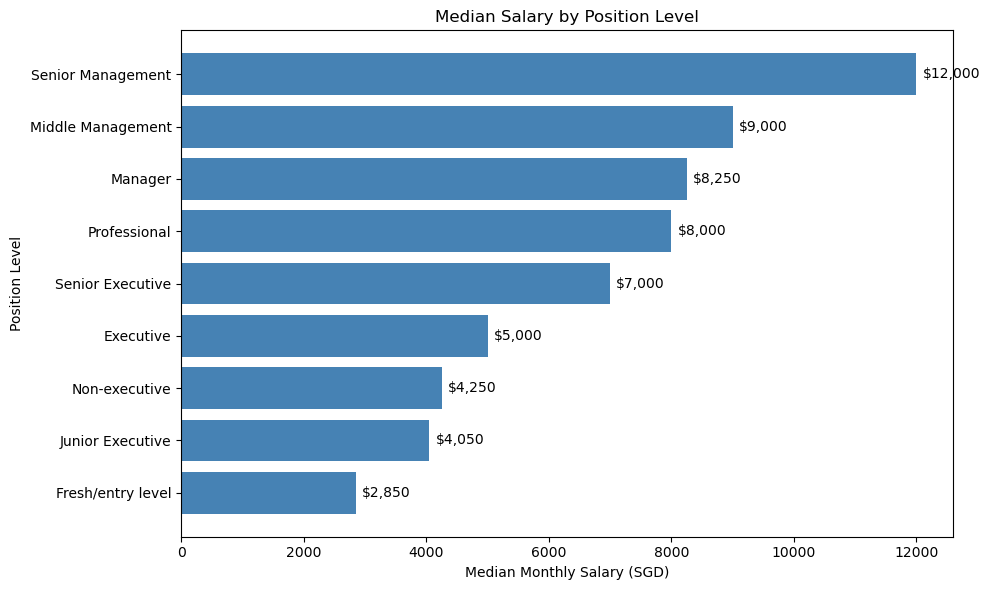

In [7]:
# ============================================================
# STEP 4: VISUALISE MEDIAN SALARY BY POSITION LEVEL
# ============================================================
# Create a horizontal bar chart to compare median salaries.

import matplotlib.pyplot as plt

chart_data = salary_by_level.sort_values(
    "median_salary",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart_data["position_level"],
    chart_data["median_salary"],
    color="steelblue"
)

plt.title("Median Salary by Position Level")
plt.xlabel("Median Monthly Salary (SGD)")
plt.ylabel("Position Level")

# Add salary labels to each bar.
for index, value in enumerate(chart_data["median_salary"]):
    plt.text(
        value + 100,
        index,
        f"${value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()